# Augmented & Fine-Tuned Model — MobileNetV2

## Purpose

This notebook builds on the baseline MobileNetV2 (`02_baseline_model_MobileNetV2.ipynb`) by combining two improvement strategies:

1. **Data augmentation** — artificially increases dataset variety by randomly transforming training images, helping the model generalise better to unseen angles, lighting, and conditions
2. **Fine-tuning** — unfreezes the top layers of the MobileNetV2 base and retrains them at a very low learning rate, allowing the pretrained features to adapt to our specific campus buildings

Both techniques address the core challenge of this project: a small dataset (~1,253 images) with high intra-class variation.

The preprocessing pipeline is imported directly from `src/preprocessing.py`.

---

## What this notebook covers

| Step | Description |
|------|-------------|
| 1. Setup & Imports | Libraries and dataset loading via `src.preprocessing` |
| 2. Load Data | Call `get_datasets()` and verify split sizes |
| 3. Data Augmentation | Define augmentation layers applied during training |
| 4. Build Model | Pretrained MobileNetV2 base + augmentation + classification head |
| 5. Phase 1 — Head Training | Freeze base, train classification head only |
| 6. Phase 2 — Fine-Tuning | Unfreeze top layers, retrain at a lower learning rate |
| 7. Evaluate | Compare best and last saved models on the test set |
| 8. Training Curves | Accuracy and loss plots across both training phases |
| 9. Misclassified Images | Visualise images the model got wrong |

---

## Strategy

Training is split into two phases:

**Phase 1 — Head training**
The MobileNetV2 base is fully frozen. Only the new classification head is trained. This is identical to the baseline and ensures the head weights are sensible before fine-tuning begins.

**Phase 2 — Fine-tuning**
The top layers of the base are unfrozen and retrained with a much lower learning rate (`1e-5`). A lower learning rate is critical here — using the same rate as Phase 1 would destroy the pretrained weights rather than gently adapting them.

---

## Expected outcome

This approach should outperform both the baseline CNN (81.52%) and the baseline MobileNetV2 (94.02%) by combining the generalisation benefits of augmentation with the feature adaptation benefits of fine-tuning.

## 1. Setup & Imports

This section imports all required libraries and loads the preprocessing pipeline from `src/preprocessing.py`.

### Path setup

Notebooks run from the `notebooks/` directory, but `src/preprocessing.py` lives one level up in the project root. Adding the project root to `sys.path` allows Python to find the `src` package when we write `from src.preprocessing import ...`.

### Constants

All image constants (`IMAGE_SIZE`, `BATCH_SIZE`, `RANDOM_SEED`) are defined in `src/preprocessing.py` and imported here to keep everything consistent across notebooks.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# tf.config.set_visible_devices([], 'GPU')

# Add the project root to sys.path so 'from src.preprocessing import ...' works
sys.path.insert(0, str(Path().resolve().parent))

from src.preprocessing import (
    get_datasets,
    IMAGE_SIZE,
    BATCH_SIZE,
    RANDOM_SEED,
)

print("TensorFlow version:", tf.__version__)
print("Image size:        ", IMAGE_SIZE)
print("Batch size:        ", BATCH_SIZE)
print("Random seed:       ", RANDOM_SEED)

TensorFlow version: 2.16.2
Image size:         (224, 224)
Batch size:         32
Random seed:        42


## 2. Load Data

This section calls `get_datasets()` from `src/preprocessing.py` which runs the full pipeline — scanning the dataset folder, splitting into train/val/test, and building `tf.data` pipelines — in a single call.

The number of batches per split is printed as a sanity check to confirm the data loaded correctly before building the model.

In [2]:
train_ds, val_ds, test_ds, class_names = get_datasets()

NUM_CLASSES = len(class_names)

print(f"Classes ({NUM_CLASSES}):       {class_names}")
print(f"Train batches:      {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches:       {len(test_ds)}")

Classes (8):       ['2', '3', '4', '5', '7', '8', '9', '10']
Train batches:      27
Validation batches: 6
Test batches:       6


2026-04-13 14:15:38.498633: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-13 14:15:38.498661: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-13 14:15:38.498667: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-13 14:15:38.498684: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-13 14:15:38.498697: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 3. Data Augmentation

Data augmentation artificially expands the training set by applying random transformations to each image on the fly. The model sees a slightly different version of each image every epoch, which improves generalisation and reduces overfitting.

### Augmentations applied

| Augmentation | Range | Reason |
|---|---|---|
| RandomFlip (horizontal) | — | Buildings can be approached from either side |
| RandomRotation | ±10% | Simulates slight camera tilt when taking photos |
| RandomZoom | ±10% | Simulates different distances from the building |

> **Note:**  and  are excluded. Our preprocessing normalises pixel values to  for MobileNetV2, but these layers expect  or  input. Applying them after normalisation corrupts the pixel values and severely degrades training performance.

### Important — augmentation is training-only

The augmentation layers are built into the model using . Keras automatically disables these layers during validation, evaluation, and inference — so the val/test results and the final Core ML model are never affected by augmentation.

In [3]:
augmentation = tf.keras.Sequential([
    # Randomly flip images horizontally
    tf.keras.layers.RandomFlip("horizontal"),
    # Small rotation to simulate handheld camera tilt
    tf.keras.layers.RandomRotation(0.1),
    # Slight zoom to simulate varying distance from building
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

## 4. Build Model

The model structure is identical to the baseline MobileNetV2 with one addition — the augmentation block is prepended to the model so it becomes part of the computational graph.

### Architecture

| Layer | Output Shape | Purpose |
|-------|-------------|---------|
| Augmentation block | (224, 224, 3) | Random transforms — training only |
| MobileNetV2 base (frozen) | (7, 7, 1280) | Pretrained ImageNet feature extraction |
| GlobalAveragePooling2D | (1280,) | Reduces spatial dimensions to a feature vector |
| Dropout(0.2) | (1280,) | Reduces overfitting |
| Dense(8, softmax) | (8,) | Outputs a probability per building class |

The base is **frozen** at this stage — it will be partially unfrozen in Phase 2 (fine-tuning). Starting with a frozen base ensures the classification head learns meaningful weights before fine-tuning begins.

In [4]:
# Load MobileNetV2 pretrained on ImageNet, without the top classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base — only the head trains in Phase 1
base_model.trainable = False

model = tf.keras.Sequential([
    # Augmentation block — only active during training, ignored at inference
    augmentation,
    # Frozen pretrained base
    base_model,
    # Average each 7x7 feature map into a single value → (1280,) vector
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Phase 1 — Head Training

In this phase the MobileNetV2 base remains fully frozen. Only the classification head (Dropout + Dense) is trained. This is the same approach as the baseline, but now with augmentation applied to every training batch.

The goal of Phase 1 is to bring the head weights to a reasonable state before fine-tuning begins. If we started fine-tuning immediately with random head weights, the large gradients from the untrained head could damage the pretrained base weights.

Models are saved to:
- `models/aug_finetuned_mobilenetv2_phase1_best.keras` — best checkpoint during Phase 1
- `models/aug_finetuned_mobilenetv2_phase1_last.keras` — end of Phase 1

In [5]:
MODELS_DIR = Path().resolve().parent / "models"
MODELS_DIR.mkdir(exist_ok=True)

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

early_stopping_p1 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_p1 = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / "aug_finetuned_mobilenetv2_phase1_best.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Phase 1 — training classification head (base frozen)")
history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping_p1, checkpoint_p1]
)

model.save(MODELS_DIR / "aug_finetuned_mobilenetv2_phase1_last.keras")
print("Phase 1 complete.")

Phase 1 — training classification head (base frozen)
Epoch 1/30


2026-04-13 14:15:40.251412: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.1720 - loss: 2.3625
Epoch 1: val_loss improved from None to 1.60971, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_phase1_best.keras

Epoch 1: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_phase1_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.2275 - loss: 2.1323 - val_accuracy: 0.4457 - val_loss: 1.6097
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.5011 - loss: 1.4157
Epoch 2: val_loss improved from 1.60971 to 1.15060, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_phase1_best.keras

Epoch 2: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_phase1_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5426 - loss: 1.3176 - val_accuracy: 0.6522 - val_loss: 1.1506
Epoch 3/30

## 6. Phase 2 — Fine-Tuning

In this phase the top layers of the MobileNetV2 base are unfrozen and retrained alongside the classification head.

### How many layers to unfreeze?

MobileNetV2 has 155 layers in total. Unfreezing all of them risks overfitting on a small dataset and is computationally expensive. A common strategy is to unfreeze only the **last 30 layers** — these are the highest-level feature detectors closest to the output, most likely to benefit from adapting to campus buildings. The earlier layers detect low-level features like edges and textures which are universal and do not need to change.

### Why a lower learning rate?

Phase 2 uses a learning rate of  — 100x smaller than Phase 1:
- The pretrained base weights are already good — they just need gentle nudging towards campus-specific features
- A high learning rate would overwrite the pretrained weights with noise rather than refining them

### Saving

Models are saved to:
-  — best checkpoint during Phase 2
-  — end of Phase 2

In [6]:
# Unfreeze the top 30 layers of the base — highest-level features
# most likely to benefit from adapting to campus-specific buildings
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable base layers: {trainable_count} / {len(base_model.layers)}")

# Recompile with a much lower learning rate to avoid overwriting pretrained weights
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"]
)

early_stopping_p2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_p2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / "aug_finetuned_mobilenetv2_best.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Phase 2 — fine-tuning top 30 base layers")
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_p2, checkpoint_p2]
)

model.save(MODELS_DIR / "aug_finetuned_mobilenetv2_last.keras")
print("Phase 2 complete.")

Trainable base layers: 30 / 154
Phase 2 — fine-tuning top 30 base layers
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 892ms/step - accuracy: 0.7077 - loss: 0.8344
Epoch 1: val_loss improved from None to 0.27197, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_best.keras

Epoch 1: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7258 - loss: 0.7833 - val_accuracy: 0.9239 - val_loss: 0.2720
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.7960 - loss: 0.5984
Epoch 2: val_loss improved from 0.27197 to 0.26776, saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_best.keras

Epoch 2: finished saving model to /Users/adamnajajreh/ltu/2. semester/DL/Capstone/models/aug_finetuned_mobilenetv2_best.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8133 - loss: 0.5

## 7. Evaluate

This section evaluates both saved Phase 2 models on the **test set** — the held-out split never seen during training or validation.

- **Best model** (`aug_finetuned_mobilenetv2_best.keras`) — saved at the epoch with the lowest `val_loss` during Phase 2
- **Last model** (`aug_finetuned_mobilenetv2_last.keras`) — saved at the end of Phase 2


In [11]:
saved_models = {
    "Best  (lowest val_loss)": MODELS_DIR / "aug_finetuned_mobilenetv2_best.keras",
    "Last  (end of training)": MODELS_DIR / "aug_finetuned_mobilenetv2_last.keras",
}

print(f"{"Model":<30} {"Loss":>8}  {"Accuracy":>10}")
print("-" * 52)

for label, model_path in saved_models.items():
    loaded_model = tf.keras.models.load_model(model_path)
    loss, acc = loaded_model.evaluate(test_ds, verbose=0)
    print(f"{label:<30} {loss:>8.4f}  {acc * 100:>9.2f}%")


Model                                   Loss    Accuracy
---------------------------------------------------------
Baseline CNN                          0.7072      81.52%
Baseline MobileNetV2                  0.2260      94.02%
Aug + MobileNetV2 Phase 1             0.3559      89.67%
Aug + Fine-Tuned MobileNetV2          0.2559      92.93%


## 8. Training Curves

Training is split across two phases so the history objects are plotted separately but shown side by side for easy comparison.

**Phase 1** — head training with frozen base and augmentation. Accuracy may climb more slowly than the baseline because augmentation makes each training batch harder.

**Phase 2** — fine-tuning with unfrozen top layers. The lower learning rate means changes are gradual — expect a smaller but meaningful improvement over Phase 1.

A growing gap between train and val accuracy in either phase indicates overfitting.

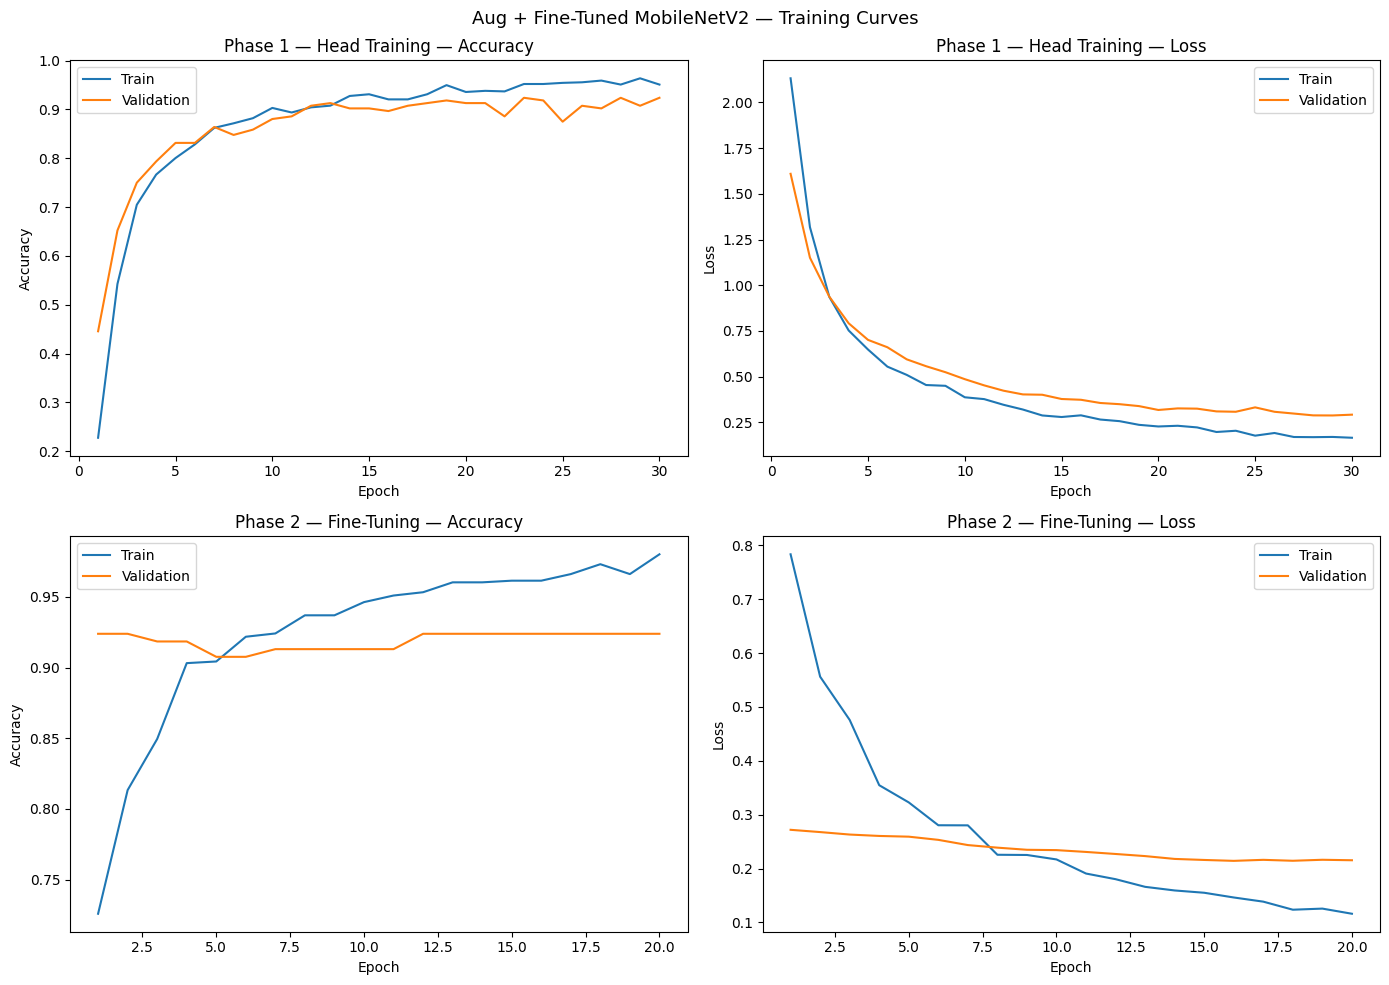

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (history, title) in enumerate([
    (history_p1, "Phase 1 — Head Training"),
    (history_p2, "Phase 2 — Fine-Tuning"),
]):
    epochs_range = range(1, len(history.history["accuracy"]) + 1)

    # Accuracy
    axes[row, 0].plot(epochs_range, history.history["accuracy"],     label="Train")
    axes[row, 0].plot(epochs_range, history.history["val_accuracy"], label="Validation")
    axes[row, 0].set_title(f"{title} — Accuracy")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Accuracy")
    axes[row, 0].legend()

    # Loss
    axes[row, 1].plot(epochs_range, history.history["loss"],     label="Train")
    axes[row, 1].plot(epochs_range, history.history["val_loss"], label="Validation")
    axes[row, 1].set_title(f"{title} — Loss")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("Loss")
    axes[row, 1].legend()

plt.suptitle("Aug + Fine-Tuned MobileNetV2 — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()


## 9. Misclassified Images

Visualising the images the final model got wrong helps identify remaining patterns in its mistakes — and compare them against the baseline to see whether augmentation and fine-tuning reduced errors on specific buildings or angles.

Loading model: aug_finetuned_mobilenetv2_best


2026-04-13 14:42:40.124949: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total images:         184
Correctly classified: 171
Misclassified:        13
Accuracy:             92.93%


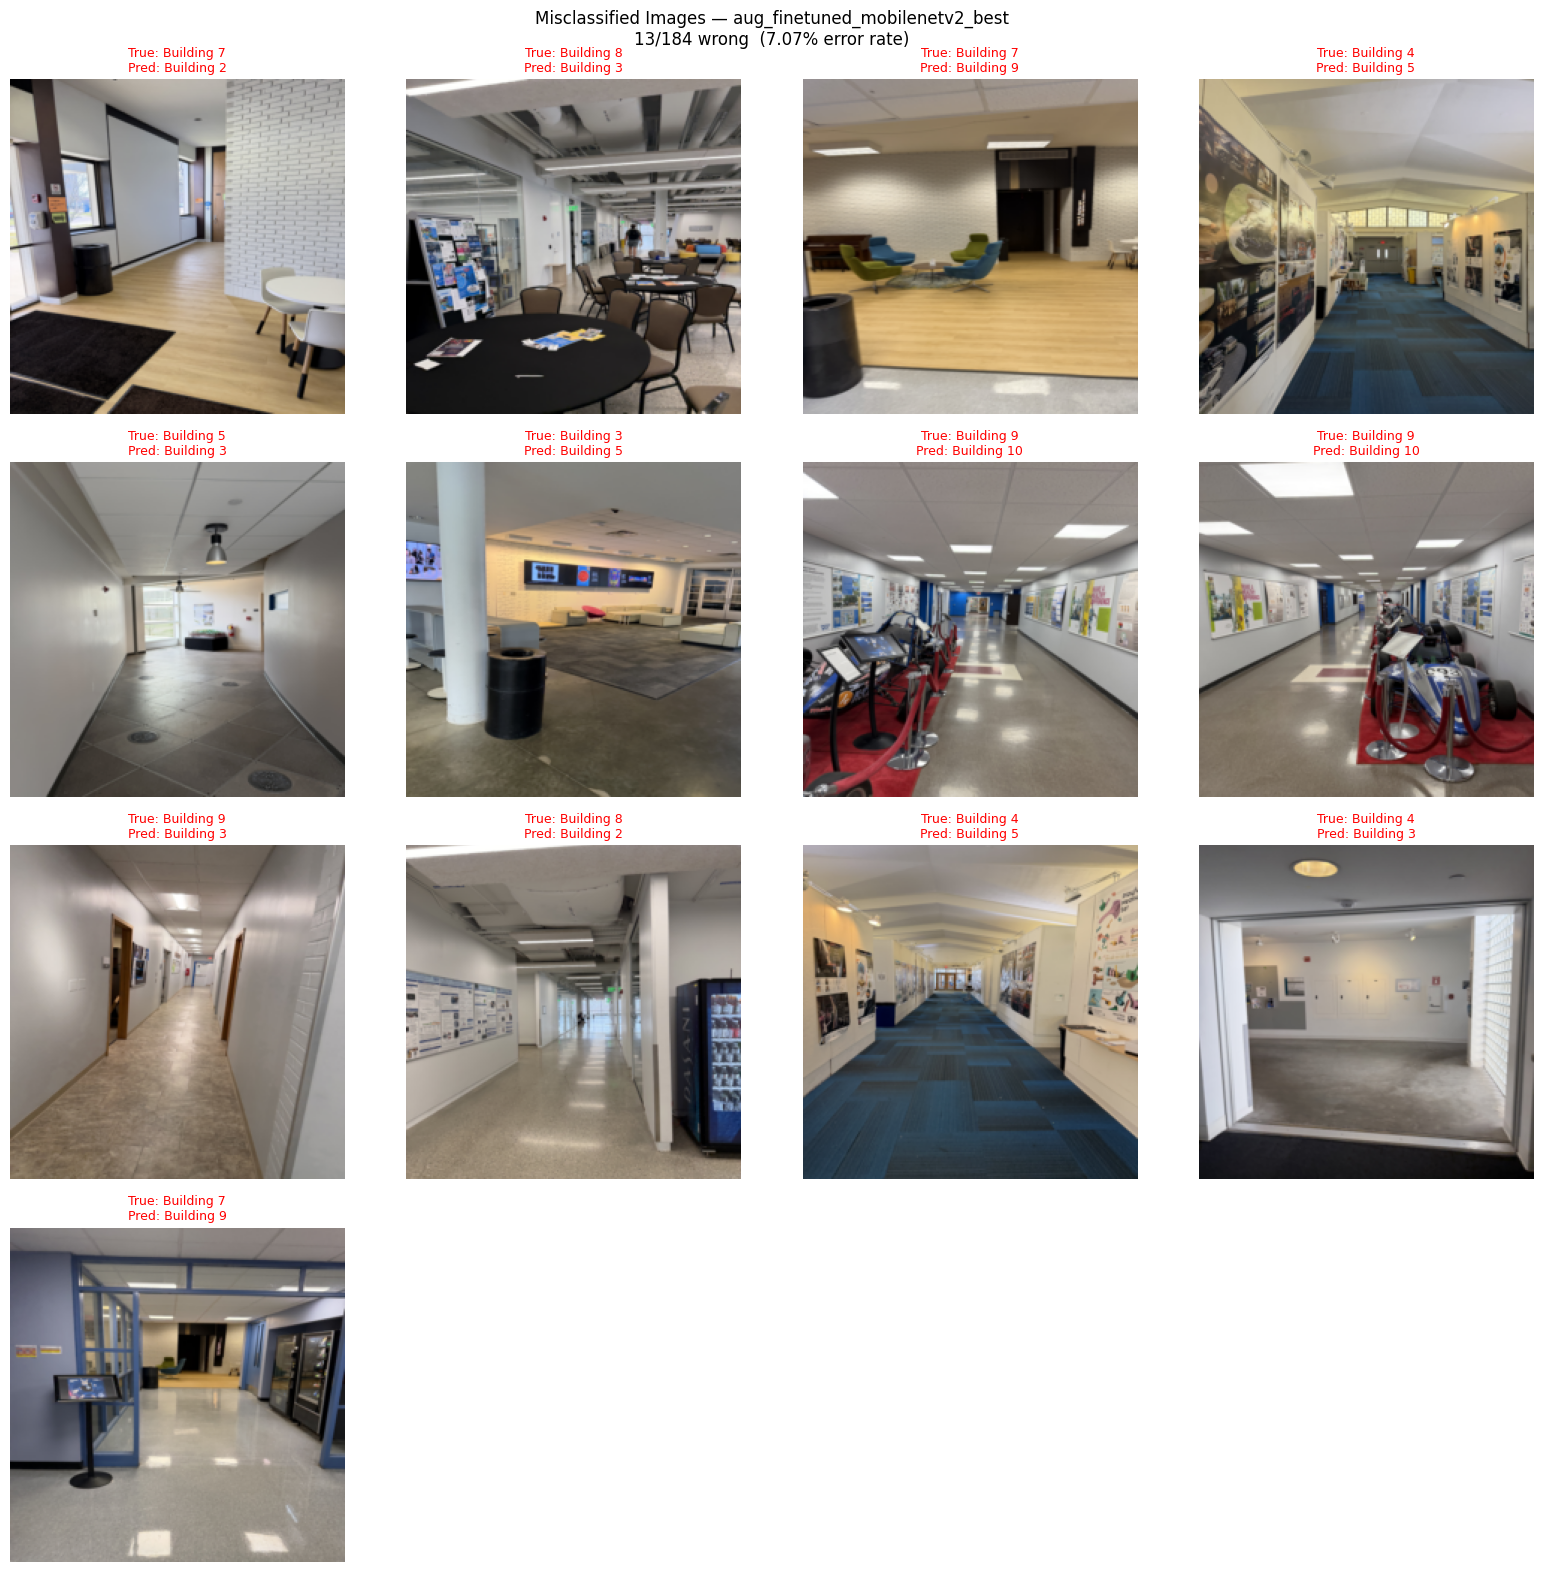

In [10]:
from src.visualize import show_misclassified

show_misclassified("aug_finetuned_mobilenetv2_best", test_ds, class_names)